In [1]:
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from scipy.optimize import minimize, curve_fit
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, add_dummy_feature

# Introduction to Machine Learning

## Practice class 04 - Regression: linear and logistic

**Introduction**
Regression is a supervised learning task where the target variable is a continuous value. We are going to review linear regression and logistic regression.

You have already seen during you previous studies that linear systems are the corner stones for a lot of methods, schemes, models etc., etc.

Linear regression tries to fit a model, a linear system of equation, to your data and pick the weights such that it minimizes a loss function. 

## Linear model

$$y_i=w_0+w_1x_i+w_2x_i^2+\cdots+w_mx_i^m+\varepsilon_i$$

$$
\begin{pmatrix} y_1\cr y_2\cr \vdots\cr y_n \end{pmatrix} =
\begin{pmatrix}
1&x_1&x_1^2&\dots &x_1^m\cr
1&x_2&x_2^2&\dots &x_2^m\cr
\vdots&\vdots&\vdots&\ddots &\vdots\cr
1&x_n&x_n^2&\dots &x_n^m\cr
\end{pmatrix}
\begin{pmatrix} w_1\cr w_2\cr \vdots\cr w_n \end{pmatrix}
+
\begin{pmatrix} \varepsilon_1\cr \varepsilon_2\cr \vdots\cr
\varepsilon_n \end{pmatrix}
$$
Solve for $\mathbf{w}$:
$$\mathbf{w}=(X^TX)^{-1}X^T \mathbf{y}$$

Why is this good? Well, not only linear model is one of the most simplistic one you can imagine, but also often is true or enough for a given problem. An with some careful data processing and transformation data can be linearized (see power law relations in log space for instance).

### What will you learn today?

1. Linear and logistic regression model
    - how do build some by hand
    - how to use already implemented ones
2. Data regularization
   - prevent over-fitting of train data paying attention 
3. A simple classification example with regression model    

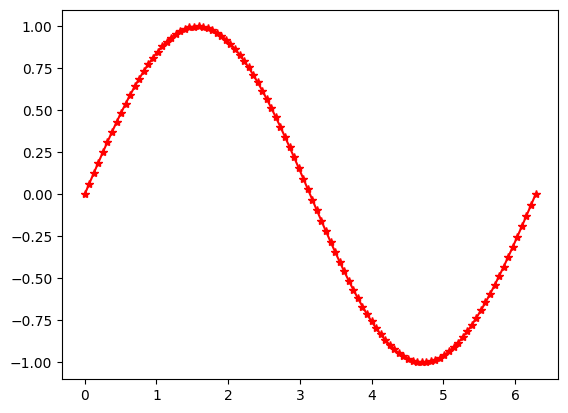

In [2]:
x = np.linspace(0,2*np.pi,100)
y = np.sin(x)
plt.plot(x,y,"r*-")

In [3]:
X = np.column_stack((x*0+1,x,x**2,x**3))

In [4]:
W = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

In [5]:
W

array([-0.18355168,  1.8797066 , -0.86959728,  0.09226714])

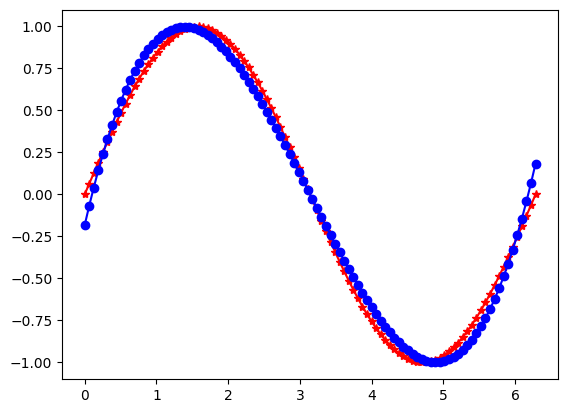

In [6]:
plt.plot(x,y,"r*-")
plt.plot(x,np.dot(W,X.T),"bo-")

In [7]:
X = np.column_stack((x*0+1,x,x**2,x**3,x**4,x**5,x**6,x**7,x**8,x**9,x**10))

In [8]:
W = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

/var/folders/dy/crwmhrjj0cqbyz9960bfh8zm0000gn/T/ipykernel_27627/679574102.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  t = [(-1)**(j//2)/np.math.factorial(j)*(j%2) for j in i]


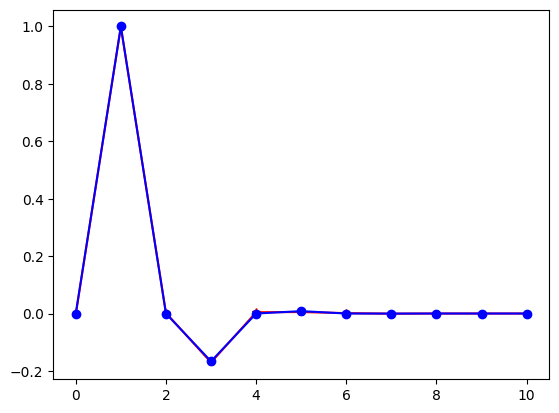

In [9]:
i = np.arange(len(W))
t = [(-1)**(j//2)/np.math.factorial(j)*(j%2) for j in i]
plt.plot(i,W,"r*-")
plt.plot(i,t,"bo-")

Taylor of sin:
$$\sin(x)=x-\frac{x^3}{3!}+\frac{x^5}{5!}+{\cal O}(x^7)$$

## Task 1: Linear Regression for Logical Operations

### Goal:
Implement a simple linear regression model to approximate the AND and XOR logical operations and analyze the results.



1. Create a dataset for the AND and XOR logical operations. Each input consists of two binary variables $(x_1, x_2)$. The target values are the results of the logical operations.
2. Scatter plot the input data points, color-coded by their target values.  

3. Use the Mean Squared Error (MSE) as loss:  
     $$0.5 \sum_i (\text{target value}_i - \text{fitted value}_i)^2$$
     The target values come from the logical operations, and the fitted values come from the model.

4. Implement a simple linear model. Define a linear function:  
     $$f(x) = w_0 + w_1 x_1 + w_2 x_2$$
     Optimize the weights \(w_0, w_1, w_2\) using `scipy.optimize.minimize`, and find optimal weights for both the AND and XOR operations.  

5. Visualize decision boundaries. Plot the decision boundaries for both AND and XOR using contour plots.  

In [ ]:
# 1. Dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)

y_and = np.array([0, 0, 0, 1], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float) 


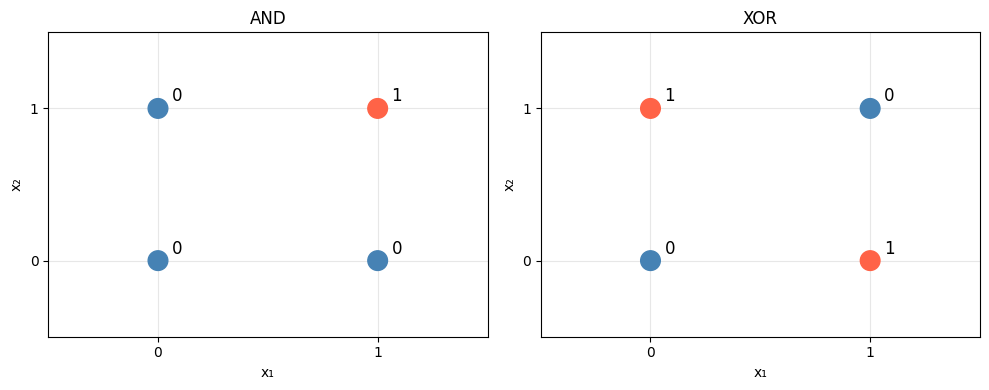

In [22]:
#2. Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y, title in zip(axes, [y_and, y_xor], ['AND', 'XOR']):
    colors = ['steelblue' if label == 0 else 'tomato' for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=200, zorder=3)
    for i, (x1, x2) in enumerate(X):
        ax.annotate(int(y[i]), (x1, x2), textcoords="offset points",
                    xytext=(10, 5), fontsize=12)
    ax.set_title(title)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# 3. Loss function
def mse_loss(weights, X, y):
    w0, w1, w2 = weights
    fitted = w0 + w1 * X[:, 0] + w2 * X[:, 1]
    return 0.5 * np.sum((y - fitted) ** 2)

In [25]:
# 4 Optimize weights
w0 = np.zeros(3)

result_and = minimize(mse_loss, w0, args=(X, y_and))
result_xor = minimize(mse_loss, w0, args=(X, y_xor))

print("AND weights (w0, w1, w2):", result_and.x)
print("XOR weights (w0, w1, w2):", result_xor.x)

AND weights (w0, w1, w2): [-0.25000001  0.5         0.5       ]
XOR weights (w0, w1, w2): [ 4.99999994e-01 -1.83780584e-09 -1.83780585e-09]


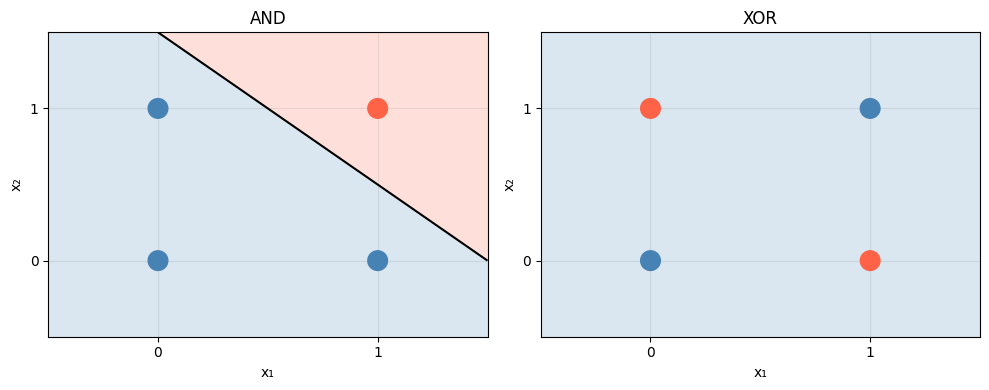

In [26]:
# 5. Decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, result, y, title in zip(axes, [result_and, result_xor], [y_and, y_xor], ['AND', 'XOR']):
    w0_, w1_, w2_ = result.x
    zz = (w0_ + w1_ * grid[:, 0] + w2_ * grid[:, 1]).reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=[-999, 0.5, 999], alpha=0.2,
                colors=['steelblue', 'tomato'])
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)

    colors = ['steelblue' if label == 0 else 'tomato' for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=200, zorder=3)

    ax.set_title(title)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 2

Implement a simple linear regression model for random data.

1. Generate some synthetic data. Take a polynomial function for instance, eg. $$x\cdot(x-0.5)\cdot(x-1)$$ and add some noise to it.
2. Plot the data.
3. Define a loss function you want to minimize. This can be for instance Root Mean Square (in practice is often bad, but really depends on the problem) or the MSE (double check if your implementation is compatible from the previous task!).
where target is the values you actually have from the data and fitted value comes from your model.
1. Implement a general polynomial function. It should take two arguments: $x$ and $w$
   - $x$ is a float, the input of the function
   - $w$ is the coefficient vector. It should have  a length of $n+1$ if you want to fit a $n$-th degree polynomial
   - then implement the good old formula of polynomial: $$f(x)=\sum_{i=0}^{n} w_ix^i$$
2. Find optimal weights for polynomials of degree $0,1,3,5,7,9$. Use `scipy.optimize.minimize` for optimum finding.
3. Plot the results!
4. You should see several interesting aspects. Mainly that the regressor starts to overfit heavily if it has a very high degree: it will hit the points, but will have a shape that does not resamble the initial data

In [45]:
# Step 1
np.random.seed(42)
x = np.linspace(0, 1, 20)
y = x * (x - 0.5) * (x - 1) + np.random.normal(0, 0.02, size=len(x))

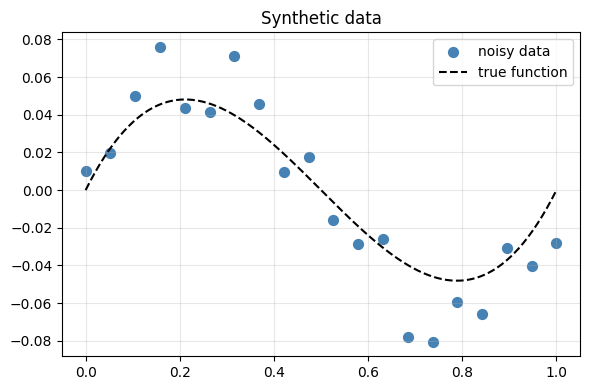

In [46]:
# Step 2
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='steelblue', s=50, label='noisy data')
x_fine = np.linspace(0, 1, 300)
plt.plot(x_fine, x_fine * (x_fine - 0.5) * (x_fine - 1), 'k--', label='true function')
plt.legend(); plt.grid(True, alpha=0.3); plt.title('Synthetic data')
plt.tight_layout(); plt.show()

In [47]:
# Step 4
def poly(x, w):
    return sum(w[i] * x**i for i in range(len(w)))

In [48]:
# Step 3
def mse_loss(weights, X, y):
    fitted = np.array([poly(xi, weights) for xi in X])
    return 0.5 * np.sum((y - fitted) ** 2)

def rms_loss(weights, X, y):
    return np.sqrt(2 * mse_loss(weights, X, y))

In [55]:
# Step 5
degrees = [0, 1, 3, 5, 7, 9, 50, 100]
results = {}
for deg in degrees:
    w0 = np.zeros(deg + 1)
    res = minimize(mse_loss, w0, args=(x, y))
    results[deg] = res.x

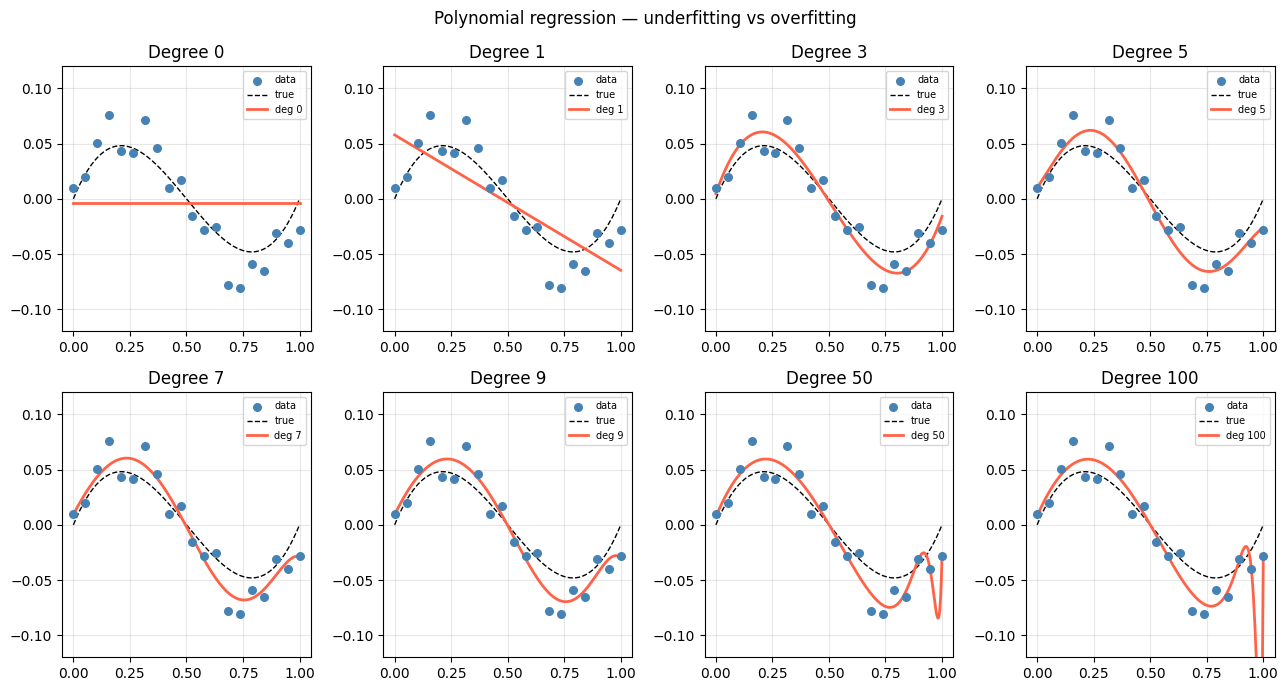

In [56]:
# Steps 6 and 7
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
x_fine = np.linspace(0, 1, 300)

for ax, deg in zip(axes.ravel(), degrees):
    w = results[deg]
    y_fine = np.array([poly(xi, w) for xi in x_fine])

    ax.scatter(x, y, color='steelblue', s=30, zorder=3, label='data')
    ax.plot(x_fine, x_fine*(x_fine-0.5)*(x_fine-1), 'k--', lw=1, label='true')
    ax.plot(x_fine, y_fine, 'tomato', lw=2, label=f'deg {deg}')
    ax.set_title(f'Degree {deg}')
    ax.set_ylim(-0.12, 0.12)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Polynomial regression — underfitting vs overfitting', fontsize=12)
plt.tight_layout(); plt.show()

## The same story in sklearn

In [10]:
X = x.reshape(-1,1)
Y = y.reshape(-1,1)
X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y
deg = 3
poly_features = PolynomialFeatures(degree=deg, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([0.])

In [11]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, Y)
lin_reg.intercept_, lin_reg.coef_

(array([-0.18355168]), array([[ 1.8797066 , -0.86959728,  0.09226714]]))

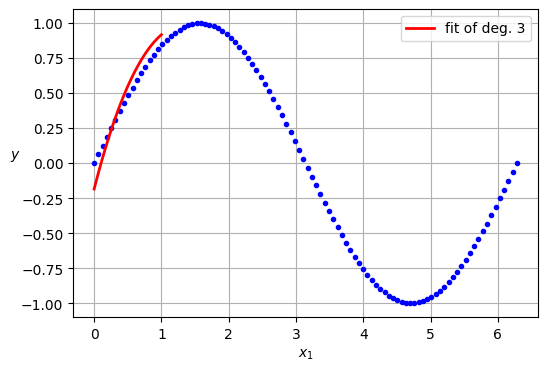

In [12]:
X_new = np.linspace(0, 1, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label=f"fit of deg. {deg}")
plt.xlabel("$x_1$")
plt.legend()
plt.ylabel("$y$", rotation=0)

plt.grid()
plt.show()

### Example of overfitting

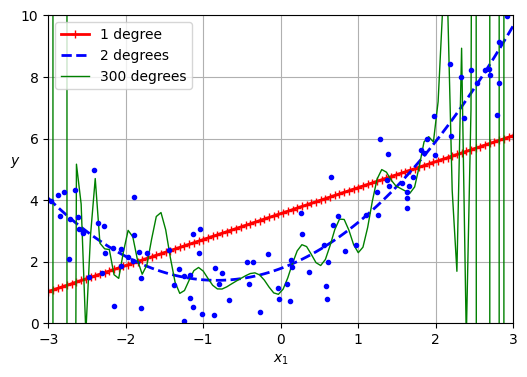

In [13]:
plt.figure(figsize=(6, 4))

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_new = np.linspace(-3, 3, 100).reshape(100, 1)

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

## Task 3: Logistic regression

1. Create a simple dataset using a **sigmoid function**:  
     $$
     y = \frac{1}{1 + e^{-(ax + b)}}
     $$ 
    Add some **Gaussian noise** to make the classification non-trivial.

2. Visualize the generated data.
3. Define the Logistic Model as:
    $$
     p = \sigma(w_0 + w_1 x)
    $$
    where $\sigma(z) = \frac{1}{1+e^{-z}}$ is the sigmoid function.

4. Define the Loss Function via the **Binary Cross-Entropy (Log Loss)** function:
     $$
     L(w) = - \sum_{i} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
     $$
    This function ensures the model predicts probabilities close to 1 for positive labels and 0 for negative labels.

5. Optimize weights as done previously via `scipy`
6. Plot the results.

In [36]:
# Step 1
np.random.seed(42)
x = np.linspace(-6, 6, 100)
a, b = 1.5, -1
y_prob = 1 / (1 + np.exp(-(a * x + b)))
y_noisy = y_prob + np.random.normal(0, 0.15, size=len(x))
y_label = (y_noisy > 0.5).astype(float)

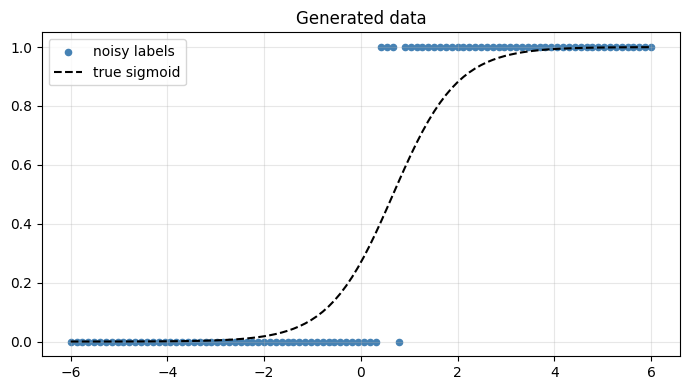

In [37]:
# Step 2
plt.figure(figsize=(7, 4))
plt.scatter(x, y_label, color='steelblue', s=20, label='noisy labels')
plt.plot(x, y_prob, 'k--', lw=1.5, label='true sigmoid')
plt.legend(); plt.grid(True, alpha=0.3); plt.title('Generated data')
plt.tight_layout(); plt.show()

In [38]:
# Step 3
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic(x, w):
    return sigmoid(w[0] + w[1] * x)

In [39]:
# Step 4
def bce_loss(weights, x, y):
    p = logistic(x, weights)
    p = np.clip(p, 1e-9, 1 - 1e-9)  # avoid log(0)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

In [40]:
# Step 5
w0 = np.zeros(2)
result = minimize(bce_loss, w0, args=(x, y_label))
w_opt = result.x
print(f"Optimized weights: w0={w_opt[0]:.3f}, w1={w_opt[1]:.3f}")
print(f"True params:       b={b:.3f},  a={a:.3f}")

Optimized weights: w0=-2.983, w1=6.152
True params:       b=-1.000,  a=1.500


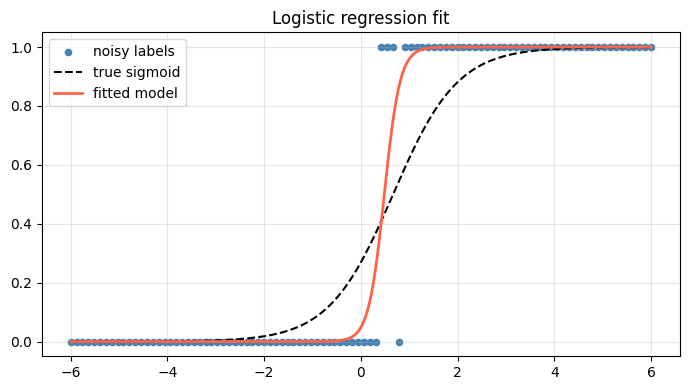

In [41]:
# Step 6: Plot results
x_fine = np.linspace(-6, 6, 300)
p_fitted = logistic(x_fine, w_opt)

plt.figure(figsize=(7, 4))
plt.scatter(x, y_label, color='steelblue', s=20, label='noisy labels')
plt.plot(x_fine, 1 / (1 + np.exp(-(a * x_fine + b))), 'k--', lw=1.5, label='true sigmoid')
plt.plot(x_fine, p_fitted, 'tomato', lw=2, label='fitted model')
plt.legend(); plt.grid(True, alpha=0.3); plt.title('Logistic regression fit')
plt.tight_layout(); plt.show()

## sklearn example

In [14]:
iris = load_iris(as_frame=True)
X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


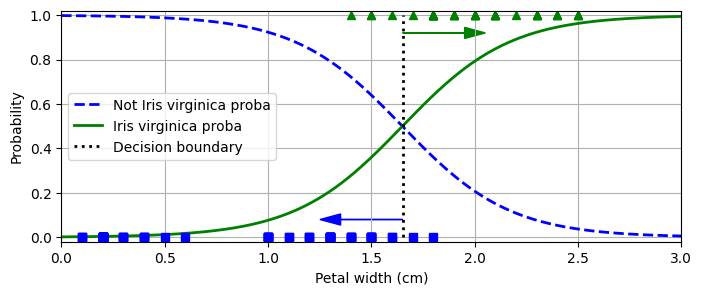

In [15]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

# extra code – this section beautifies and saves Figure 4–23
plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()

plt.show()

## Task 4: Classification and regularization with regression



In [16]:
# Generate Multiclass Data
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_classes=3, n_clusters_per_class=1, n_redundant=0)

# One-hot encoding for multiclass logistic regression
y_one_hot = np.zeros((y.size, y.max() + 1))
y_one_hot[np.arange(y.size), y] = 1

In [17]:

# Define Softmax Function
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Stability trick
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Define Multiclass Logistic Regression Model
def multiclass_model(W, X):
    return softmax(X @ W)  # Linear transformation + softmax activation

# Define Loss Function (Cross-Entropy)
def cross_entropy_loss(W, args):
    X, y = args
    m, n_classes = y.shape
    W = W.reshape((-1, n_classes))
    p = multiclass_model(W, X)
    return -np.sum(y * np.log(p + 1e-10)) / m


In [18]:
# Optimize Model Parameters
W_init = np.zeros((X.shape[1], y_one_hot.shape[1]))
W_opt = minimize(cross_entropy_loss, W_init.ravel(), [X, y_one_hot], method='BFGS').x.reshape(X.shape[1], -1)


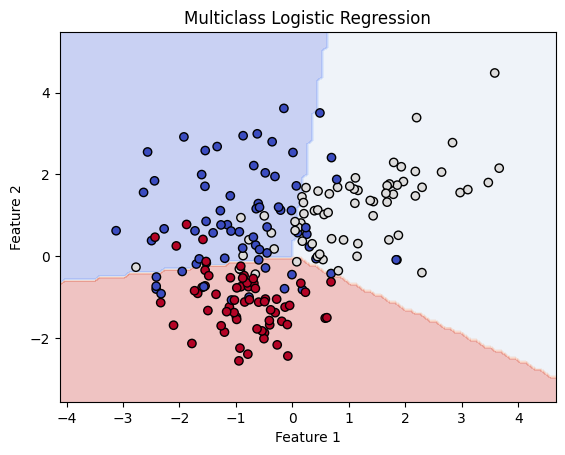

Optimized Weights: [[-0.75091997  1.10692537 -0.35600538]
 [ 0.9019402   0.68942193 -1.59136226]]


In [19]:

# Predict and Visualize Decision Boundaries
def predict(X, W):
    return np.argmax(multiclass_model(W, X), axis=1)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = predict(np.c_[xx.ravel(), yy.ravel()], W_opt).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title('Multiclass Logistic Regression')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Print optimized weights
print("Optimized Weights:", W_opt)


# Homeworks

## Task 1
**Total 4 points**


We showed during the previous exercises, that the chosen weight is quite sensitive to the loss. Now how can we tell the model to behave in more general way and to not over-fit on training data? Via **regularization**!

There are many ways and methods to do this, but two wide spread are `Ridge` and `Lasso` regularization. Your task is:

1. Take the `sklearn` examples from the class material. 
2. Based on those new linear regressors:
   1. `Ridge`. Loss:
        $$J(\theta) = MSE(\theta) + \alpha\frac{1}{2}\sum_{i=1}^{n}\theta_i^2$$
   2. `Lasso`
        $$J(\theta) = MSE(\theta) + \alpha\sum_{i=1}^{n}\lvert\theta_i\rvert$$
   3. `SGDRegressor`
3. Fit these models for the same data! They all have an extra parameter called `alpha` check what happens if you use different values. Please play around, different models work with different values. Pick at least 3 different for each!!!!
4. Remeber to add `PolyinomialFeatures`
5. Also fit the data for different polynomial degrees.
5. Plot what you get! You should see that if you increase the regularizaton parameter, the higher order polynomials come with less overfitting.

**Idea**: Play with `StandardScaler`.



## Task 2
**Total 6 points**

An Ecommerce company based in New York City sells clothing online but they also have in-store style and clothing advice sessions. Customers come in to the store, have sessions/meetings with a personal stylist, then they can go home and order either on a mobile app or website for the clothes they want.

The company is trying to decide whether to focus their efforts on their mobile app experience or their website. They've hired you on contract to help them figure it out! Let's get started!

You'll work with the `ecommerce_customers.csv` file from the company. It has Customer info, suchas Email, Address, and their color Avatar. Then it also has numerical value columns:

* Avg. Session Length: Average session of in-store style advice sessions.
* Time on App: Average time spent on App in minutes
* Time on Website: Average time spent on Website in minutes
* Length of Membership: How many years the customer has been a member.

1. Explore the data to find the most correlated quantity to "Annual Spent" 
2. Split the data into test and train and train a linear regressor (you can use sklearn's `train_test_split` function)
3. Predict for the test set
4. Evaluate the model (via error functions, such as MSE, MAE, RMSE) and formulate a conclusion on which department the company should invest!

In [20]:
import pandas as pd
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split